In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
data = pd.read_csv("shuttle.csv")
data

,Date,Count,Temperature,Pressure,Malfunction
0,4/12/81,6,66,50,0
1,11/12/81,6,70,50,1
2,3/22/82,6,69,50,0
3,11/11/82,6,68,50,0
4,4/04/83,6,67,50,0
5,6/18/82,6,72,50,0
6,8/30/83,6,73,100,0
7,11/28/83,6,70,100,0
8,2/03/84,6,57,200,1
9,4/06/84,6,63,200,1


##   Distribution of temperature and malfunctions

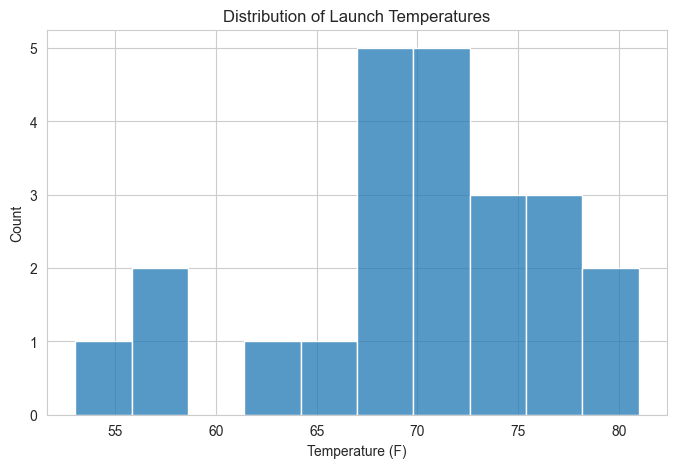

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(data=data, x="Temperature", bins=10)
plt.title("Distribution of Launch Temperatures")
plt.xlabel("Temperature (F)")
plt.show()

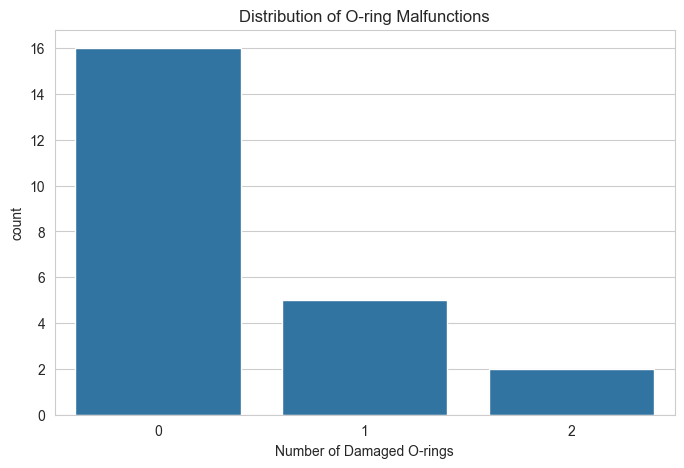

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(data=data, x="Malfunction")
plt.title("Distribution of O-ring Malfunctions")
plt.xlabel("Number of Damaged O-rings")
plt.show()

most launches occured at high temperature and most of launches have 0 O-rings damage

### Relationship between temperature and O-ring damage

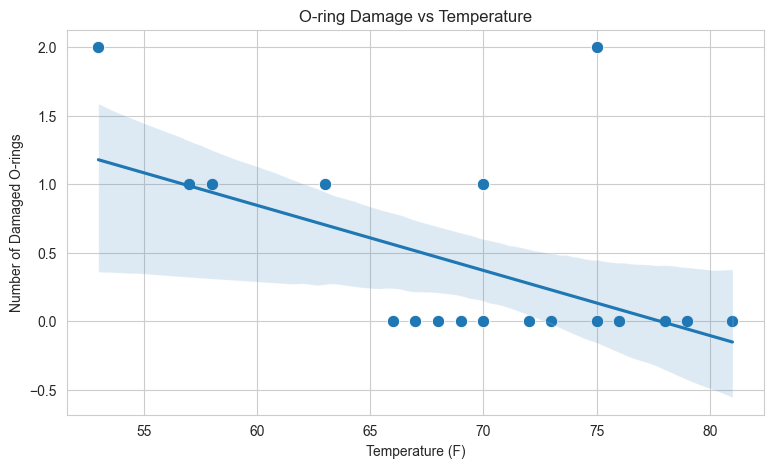

In [7]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=data, x="Temperature", y="Malfunction", s=80)
sns.regplot(data=data, x="Temperature", y="Malfunction", scatter=False)
plt.title("O-ring Damage vs Temperature")
plt.xlabel("Temperature (F)")
plt.ylabel("Number of Damaged O-rings")
plt.show()

Here we see a strong negative correlation, lower temperature associated with higher numbers of damaged O-rings

### Any damage vs Temperature

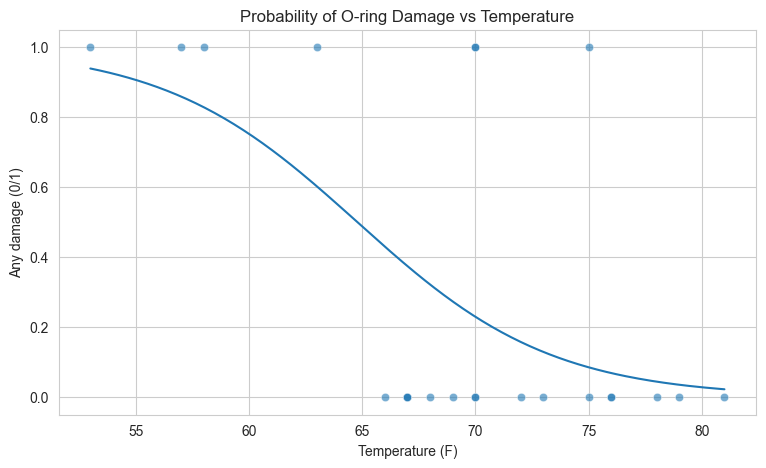

In [10]:
data["AnyDamage"] = (data["Malfunction"] > 0).astype(int)

X = sm.add_constant(data["Temperature"])
y = data["AnyDamage"]
logit = sm.Logit(y, X).fit(disp=False)

temps = np.linspace(data["Temperature"].min(), data["Temperature"].max(), 200)
pred = logit.predict(sm.add_constant(temps))

plt.figure(figsize=(9,5))
sns.scatterplot(data=data, x="Temperature", y="AnyDamage", alpha=0.6)
plt.plot(temps, pred)
plt.title("Probability of O-ring Damage vs Temperature")
plt.xlabel("Temperature (F)")
plt.ylabel("Any damage (0/1)")
plt.show()

We see,that damage becomes more likely as temperature decrease
This binary view represets risk

### Only failures

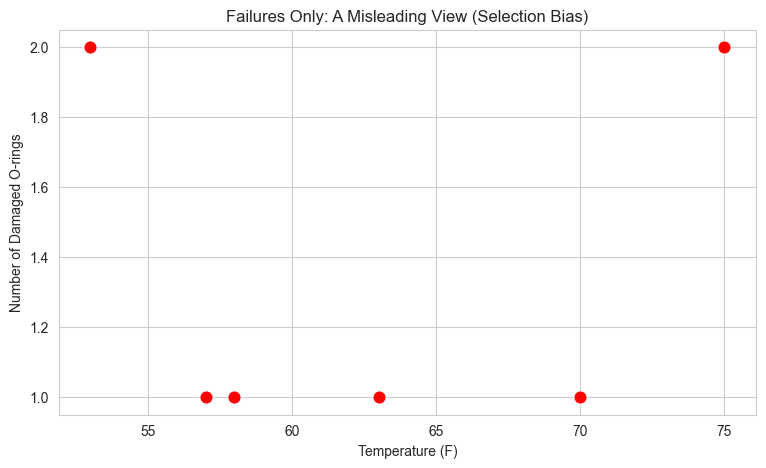

In [11]:
failures_only = data[data["Malfunction"] > 0]

plt.figure(figsize=(9,5))
sns.scatterplot(data=failures_only, x="Temperature", y="Malfunction", color="red", s=90)
plt.title("Failures Only: A Misleading View (Selection Bias)")
plt.xlabel("Temperature (F)")
plt.ylabel("Number of Damaged O-rings")
plt.show()

Removing zero damage launches discards crucial information
It can hide how strongly low temperatures increase fail risk

### Risk estimation at 31 degree

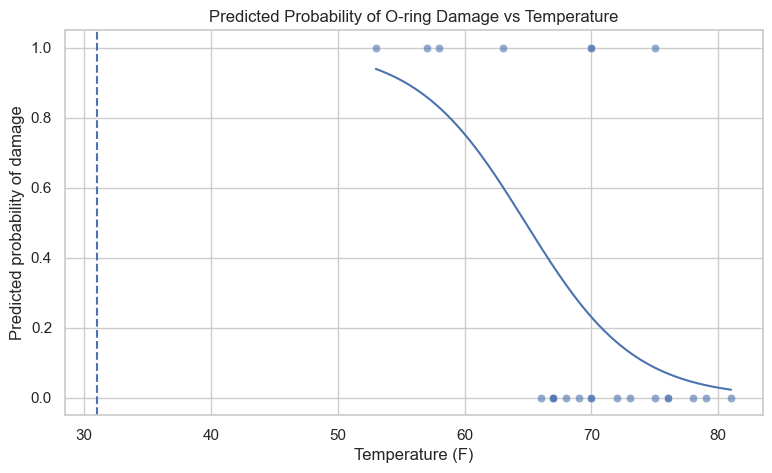

np.float64(0.9996087828849319)

In [ ]:
X = sm.add_constant(data["Temperature"])
y = data["AnyDamage"]

model = sm.Logit(y, X).fit(disp=False)

temps = np.linspace(data["Temperature"].min(), data["Temperature"].max(), 200)
pred = model.predict(sm.add_constant(temps))

p31 = model.predict(pd.DataFrame({"const":[1.0], "Temperature":[31.0]})).iloc[0]

plt.figure(figsize=(9,5))
sns.scatterplot(data=data, x="Temperature", y="AnyDamage", alpha=0.6)
plt.plot(temps, pred)
plt.axvline(31, linestyle="--")
plt.title("Predicted Probability of O-ring Damage vs Temperature")
plt.xlabel("Temperature (F)")
plt.ylabel("Predicted probability of damage")
plt.show()
p31


The predicted probability of O-ring damage at 31F is high
This prediction relies on extrapolation beyond most observed temperatures

### Pressure impact on O-ring damage

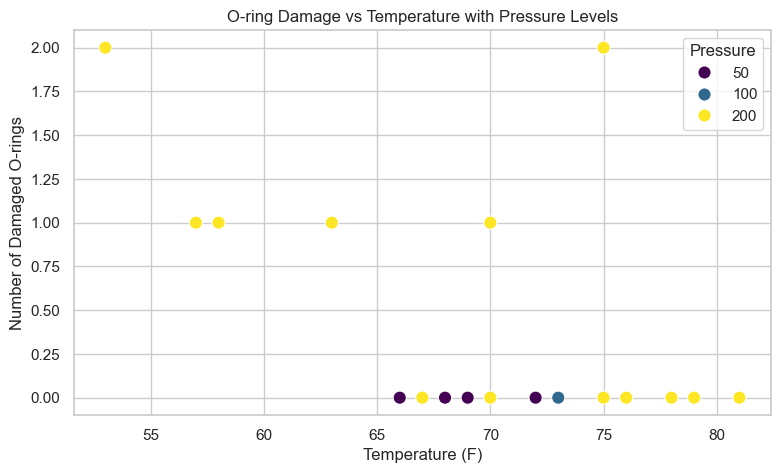

In [16]:
plt.figure(figsize=(9,5))
sns.scatterplot(
    data=data,
    x="Temperature",
    y="Malfunction",
    hue="Pressure",
    palette="viridis",
    s=90
)
plt.title("O-ring Damage vs Temperature with Pressure Levels")
plt.xlabel("Temperature (F)")
plt.ylabel("Number of Damaged O-rings")
plt.show()


Pressure doesn't show a clear relationship with O-ring damage,the temperature remains the dominant factor

### Conclusion

The analysis shows a strong relationship between launch temperature and O-ring damage: lower temperatures is associating  with a higher probability of fail. Reformulating the problem as a binary outcome confirms that the risk of observing damage increases sharply as temperature decreases. The estimated risk at 31°F, the Challenger launch temperature  is high, although this result relies on extrapolation beyond the range of observed data. Pressure level analysis doesn't reveal a clear effect, suggesting that temperature is the primary factor of O-ring damage. This case demonstrates the importance of considering all available data and avoiding selection bias when evaluation  safety risks